# 07 — Hidden Gem Finder
**Finding Hidden Gems: 25 Years of WNBA Draft Value and Player Success**

Packages the Draft Steal Score (Notebook 04) into the specific leaderboards a front
office would actually want to page through: best steals, most underrated classes, best
second-round finds, most overlooked programs, and international success stories.

All tables here exclude the 2021-2022 draft classes (too little career to judge), same
as every notebook since 04.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
COLOR_MAIN = '#E56020'
COLOR_ALT  = '#1B3A5C'

clean = pd.read_csv('../data/wnba_draft_clean.csv')
steals = pd.read_csv('../data/draft_steal_scores.csv')
judgeable = steals[~steals['too_early_to_judge']].copy()
print(f"{len(judgeable)} judgeable picks (2021-2022 excluded)")


992 judgeable picks (2021-2022 excluded)


## 1. Best Steals Ever

In [2]:
best_steals_ever = judgeable.nlargest(15, 'steal_score')[
    ['player','year','overall_pick','round','team','college_display','win_shares_ev','expected_win_shares','steal_score']
].rename(columns={'win_shares_ev': 'career_win_shares'})
best_steals_ever.round(2)


,player,year,overall_pick,round,team,college_display,career_win_shares,expected_win_shares,steal_score
188,Tamika Catchings,2001,3,1,Indiana Fever,Tennessee,93.7,17.45,76.25
103,Taj McWilliams-Franklin,1999,32,3,Orlando Miracle,St. Edward's,53.9,0.05,53.85
515,Sylvia Fowles,2008,2,1,Chicago Sky,LSU,73.5,19.83,53.67
186,Lauren Jackson,2001,1,1,Seattle Storm,NaN,73.0,22.22,50.78
356,Diana Taurasi,2004,1,1,Phoenix Mercury,UConn,71.2,22.22,48.98
196,Penny Taylor,2001,11,1,Cleveland Rockers,NaN,49.0,1.84,47.16
195,Katie Douglas,2001,10,1,Orlando Miracle,Purdue,48.9,2.88,46.02
365,Rebekkah Brunson,2004,10,1,Sacramento Monarchs,Georgetown,48.6,2.88,45.72
359,Lindsay Whalen,2004,4,1,Connecticut Sun,Minnesota,59.8,15.08,44.72
514,Candace Parker,2008,1,1,Los Angeles Sparks,Tennessee,62.2,22.22,39.98


## 2. Most Underrated Draft Classes

Summing steal score across an entire class measures whether that year's draft, as a
whole, delivered more total value than the pick slots implied — a proxy for "deep,
underrated class" vs. "shallow class that even the top picks struggled to justify."


In [3]:
class_strength = judgeable.groupby('year').agg(
    picks=('player', 'count'),
    total_steal_score=('steal_score', 'sum'),
    avg_steal_score=('steal_score', 'mean'),
    total_win_shares=('win_shares_ev', 'sum'),
).sort_values('total_steal_score', ascending=False)

print("Most underrated draft classes (highest total value above expectation):")
print(class_strength.head(8).round(2))
print()
print("Most overrated / shallow draft classes (most total value below expectation):")
print(class_strength.tail(8).round(2))


Most underrated draft classes (highest total value above expectation):
      picks  total_steal_score  avg_steal_score  total_win_shares
year                                                             
1999     50             381.47             7.63             506.4
2001     64             316.46             4.94             441.3
2004     38             204.27             5.38             329.1
2008     43             183.69             4.27             308.6
2009     39             101.65             2.61             226.5
2006     42              91.40             2.18             216.3
2011     36              86.02             2.39             210.8
2002     64              83.96             1.31             208.8

Most overrated / shallow draft classes (most total value below expectation):
      picks  total_steal_score  avg_steal_score  total_win_shares
year                                                             
2016     36              -8.18            -0.23            

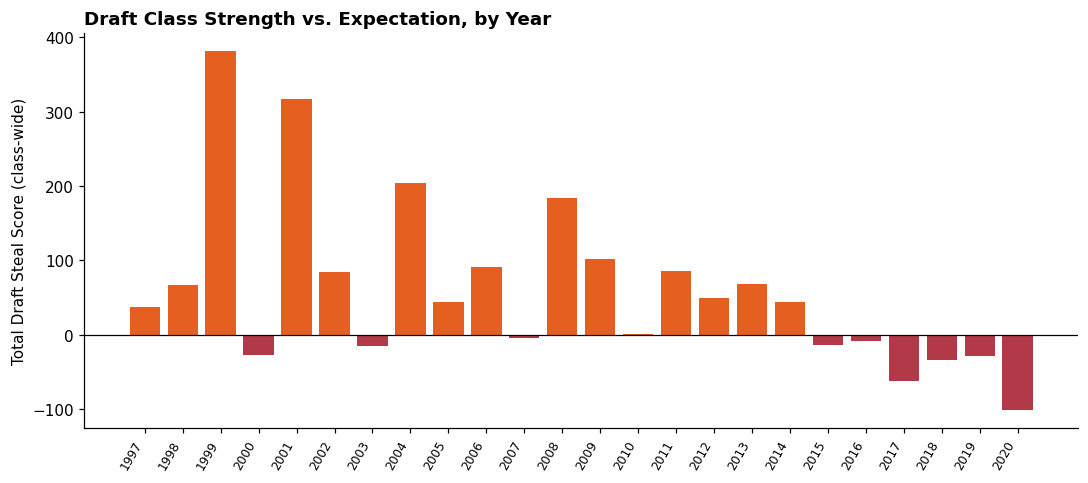

In [4]:
fig, ax = plt.subplots(figsize=(10, 4.5))
colors = ['#E56020' if v >= 0 else '#B23A48' for v in class_strength.sort_index()['total_steal_score']]
ax.bar(class_strength.sort_index().index.astype(str), class_strength.sort_index()['total_steal_score'], color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Total Draft Steal Score (class-wide)')
ax.set_title('Draft Class Strength vs. Expectation, by Year', loc='left', fontweight='bold')
plt.xticks(rotation=60, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('../dashboard/chart_class_strength.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Most Valuable Second-Round Picks

In [5]:
second_round_gems = judgeable[judgeable['round'] == 2].nlargest(12, 'steal_score')[
    ['player','year','overall_pick','team','college_display','win_shares_ev','expected_win_shares','steal_score']
].rename(columns={'win_shares_ev': 'career_win_shares'})
second_round_gems.round(2)


,player,year,overall_pick,team,college_display,career_win_shares,expected_win_shares,steal_score
203,Tammy Sutton-Brown,2001,18,Charlotte Sting,Rutgers,32.9,0.12,32.78
722,Emma Meesseman,2013,19,Washington Mystics,NaN,29.2,0.11,29.09
681,Tiffany Hayes,2012,14,Atlanta Dream,UConn,28.4,0.42,27.98
43,Tangela Smith,1998,12,Sacramento Monarchs,Iowa,27.8,1.14,26.66
13,Tamecka Dixon,1997,14,Los Angeles Sparks,Kansas,22.5,0.42,22.08
491,Camille Little,2007,17,San Antonio Stars,UNC,21.7,0.16,21.54
538,Leilani Mitchell,2008,25,Phoenix Mercury,Utah,21.0,0.05,20.95
612,Alysha Clark,2010,17,San Antonio Stars,Middle Tennessee,20.6,0.16,20.44
91,Sheri Sam,1999,20,Orlando Miracle,Vanderbilt,20.4,0.10,20.30
535,Allie Quigley,2008,22,Seattle Storm,DePaul,18.9,0.09,18.81


## 4. Most Overlooked Colleges

Programs that don't produce many WNBA picks (10 or fewer across the full 25-year dataset —
i.e. not a traditional powerhouse) but whose picks, on average, meaningfully outproduce
their draft slot. Minimum 3 judgeable picks to filter out pure one-hit noise.


In [6]:
pedigree = clean.groupby('college_display').size().rename('total_picks_alltime')
college_value = judgeable.merge(pedigree, left_on='college_display', right_index=True, how='left')

overlooked_colleges = (college_value.groupby('college_display')
    .agg(judged_picks=('player', 'count'),
         total_picks_alltime=('total_picks_alltime', 'first'),
         avg_steal_score=('steal_score', 'mean'),
         total_win_shares=('win_shares_ev', 'sum'))
    .query('judged_picks >= 3 and total_picks_alltime <= 10')
    .sort_values('avg_steal_score', ascending=False)
    .head(12))
overlooked_colleges.round(2)


,judged_picks,total_picks_alltime,avg_steal_score,total_win_shares
college_display,,,,
Georgetown,3,3.0,18.34,58.3
Temple,4,4.0,9.47,49.5
Saint Joseph's,3,3.0,6.98,21.5
Auburn,6,7.0,6.38,51.3
Texas Tech,8,8.0,4.84,58.4
Middle Tennessee,4,4.0,4.75,36.2
George Washington,6,6.0,3.86,33.7
Old Dominion,10,10.0,3.41,55.7
Marquette,3,3.0,2.47,7.6


## 5. International Success Stories

In [7]:
international_gems = judgeable[judgeable['is_international']].nlargest(12, 'steal_score')[
    ['player','year','overall_pick','round','team','win_shares_ev','expected_win_shares','steal_score']
].rename(columns={'win_shares_ev': 'career_win_shares'})
international_gems.round(2)


,player,year,overall_pick,round,team,career_win_shares,expected_win_shares,steal_score
186,Lauren Jackson,2001,1,1,Seattle Storm,73.0,22.22,50.78
196,Penny Taylor,2001,11,1,Cleveland Rockers,49.0,1.84,47.16
722,Emma Meesseman,2013,19,2,Washington Mystics,29.2,0.11,29.09
414,Erin Phillips,2005,21,2,Connecticut Sun,13.1,0.09,13.01
65,Sandy Brondello,1998,34,4,Detroit Shock,12.4,0.04,12.36
679,Damiris Dantas,2012,12,1,Minnesota Lynx,10.9,1.14,9.76
130,Kamila Vodichkova,2000,9,1,Seattle Storm,13.3,4.31,8.99
931,Ezi Magbegor,2019,12,1,Seattle Storm,6.9,1.14,5.76
772,Stephanie Talbot,2014,33,3,Phoenix Mercury,5.4,0.05,5.35
32,Margo Dydek,1998,1,1,Utah Starzz,26.8,22.22,4.58


In [8]:
intl_summary = judgeable[judgeable['is_international']].agg(
    picks=('player', 'count'),
    avg_steal_score=('steal_score', 'mean'),
    steal_rate=('steal_score', lambda s: (s > 0).mean()),
)
print("International picks overall:")
print(intl_summary)
print()
print(f"Compare to overall judgeable pool avg steal score: {judgeable['steal_score'].mean():.2f}")


International picks overall:
                 player  steal_score
picks              74.0          NaN
avg_steal_score     NaN     2.352507
steal_rate          NaN     0.391892

Compare to overall judgeable pool avg steal score: 1.47


## Save hidden gem tables

In [9]:
best_steals_ever.to_csv('../data/gems_best_steals.csv', index=False)
class_strength.reset_index().to_csv('../data/gems_class_strength.csv', index=False)
second_round_gems.to_csv('../data/gems_second_round.csv', index=False)
overlooked_colleges.reset_index().to_csv('../data/gems_overlooked_colleges.csv', index=False)
international_gems.to_csv('../data/gems_international.csv', index=False)
print("Saved 5 hidden-gem tables to data/")


Saved 5 hidden-gem tables to data/
